In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import re
import os
import glob
import sys
from tqdm import tqdm
import datetime
import gc
import numpy as np
import tensorflow as tf

In [3]:
config = {
    'project_path': 'drive/MyDrive/author-handwriting-recog',
    'dataset': 'complete_dataset_20260122-142244.tar.gz',
    'authors': 50,
    'authors_range': range(50),
    'input_shape': (113, 113, 1),
    'embedding_dim': 256,
    'epochs': 15,
    'seed': 42,
    'batch_size': {
        'train': 64,
        'validation': 16,
        'test': 8
    }
}

In [4]:
sys.path.insert(0, config['project_path'])

In [5]:
sys.path

['drive/MyDrive/author-handwriting-recog',
 '/content',
 '/env/python',
 '/usr/lib/python312.zip',
 '/usr/lib/python3.12',
 '/usr/lib/python3.12/lib-dynload',
 '',
 '/usr/local/lib/python3.12/dist-packages',
 '/usr/lib/python3/dist-packages',
 '/usr/local/lib/python3.12/dist-packages/IPython/extensions',
 '/root/.ipython']

In [6]:
!pip install "zarr>=2.16.0,<3.0.0" numcodecs

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.3/211.3 kB 19.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 135.0 MB/s eta 0:00:00
  Created wheel for asciitree: filename=asciitree-0.3.3-py3-none-any.whl size=5031 sha256=debb0e13b3a923bc4f23a4ae005c4072f791396b922ef34f92aa4cf418759f30
  Stored in directory: /root/.cache/pip/wheels/a5/d7/98/f56ae733748cd0fa577172bda0e73e0b1f1793c98e09b9e458
Successfully built asciitree


In [7]:
from src.io.exceptions import DeserializationError
from src.io.logging import LoggerFactory
from src import SelectiveDataLoader
from src.io import load

In [8]:
dataset_path = f"{config['project_path']}/data/datasets/{config['dataset']}"

In [9]:
current_time = datetime.datetime.now().strftime("%Y%m%d-%H%M%S")

In [10]:
logger = LoggerFactory.get_notebook_logger("code_1", log_dir=f"./logs_{current_time}")

In [11]:
!tar -xzf {dataset_path} -C ./

In [12]:
loader = SelectiveDataLoader(
        dataset_path="./complete_dataset_20260122-142244.zarr",
        load_fn=load
        )

17:00:10 - ZarrSerializer - INFO - Initialized with blosc compression (level 5)
17:00:10 - ZarrSerializer - INFO - ======================================================================
17:00:10 - ZarrSerializer - INFO - Loading Zarr dataset: complete_dataset_20260122-142244.zarr
17:00:10 - ZarrSerializer - INFO - ======================================================================
17:00:10 - ZarrSerializer - INFO - 📂 Loading partition (lazy mode)...
17:00:10 - ZarrSerializer - INFO -    ├─ train: 1,268,876 patches (~34851MB, lazy-loaded)
17:00:10 - ZarrSerializer - INFO -    ├─ validation: 206,216 patches (~5664MB, lazy-loaded)
17:00:10 - ZarrSerializer - INFO -    ├─ test: 51,067 patches (~1403MB, lazy-loaded)
17:00:10 - ZarrSerializer - INFO -    └─ Partition loaded (data not yet in memory)
17:00:10 - ZarrSerializer - INFO - 📂 Loading 'labels': (1526159,), 5.8MB
17:00:10 - ZarrSerializer - INFO - 📂 Loading metadata: 5 items
17:00:10 - ZarrSerializer - INFO - ======================

In [13]:
from src.datasets import SubsetBuilder, PairGenerator, DataGenerator, TripletGenerator

In [14]:
subset_builder = SubsetBuilder(
    loader=loader,
)

In [15]:
subset = subset_builder.build(
    authors_range=config['authors_range'],
    show_progress_bar=True,
)

17:00:10 - ZarrSerializer - INFO - ======================================================================
17:00:10 - ZarrSerializer - INFO - Loading Zarr dataset: complete_dataset_20260122-142244.zarr
17:00:10 - ZarrSerializer - INFO - ======================================================================
17:00:10 - ZarrSerializer - INFO - 📂 Loading partition (lazy mode)...
17:00:10 - ZarrSerializer - INFO -    ├─ train: 1,268,876 patches (~34851MB, lazy-loaded)
17:00:10 - ZarrSerializer - INFO -    ├─ validation: 206,216 patches (~5664MB, lazy-loaded)
17:00:10 - ZarrSerializer - INFO -    ├─ test: 51,067 patches (~1403MB, lazy-loaded)
17:00:10 - ZarrSerializer - INFO -    └─ Partition loaded (data not yet in memory)
17:00:10 - ZarrSerializer - INFO - 📂 Loading 'labels': (1526159,), 5.8MB
17:00:10 - ZarrSerializer - INFO - 📂 Loading metadata: 5 items
17:00:10 - ZarrSerializer - INFO - ======================================================================
17:00:10 - ZarrSerializer - INF

Loading train: 100%|██████████| 50/50 [00:16<00:00,  2.97it/s]


17:00:29 - ZarrSerializer - INFO - ======================================================================
17:00:29 - ZarrSerializer - INFO - Loading Zarr dataset: complete_dataset_20260122-142244.zarr
17:00:29 - ZarrSerializer - INFO - ======================================================================
17:00:29 - ZarrSerializer - INFO - 📂 Loading partition (lazy mode)...
17:00:29 - ZarrSerializer - INFO -    ├─ train: 1,268,876 patches (~34851MB, lazy-loaded)
17:00:29 - ZarrSerializer - INFO -    ├─ validation: 206,216 patches (~5664MB, lazy-loaded)
17:00:29 - ZarrSerializer - INFO -    ├─ test: 51,067 patches (~1403MB, lazy-loaded)
17:00:29 - ZarrSerializer - INFO -    └─ Partition loaded (data not yet in memory)
17:00:29 - ZarrSerializer - INFO - 📂 Loading 'labels': (1526159,), 5.8MB
17:00:29 - ZarrSerializer - INFO - 📂 Loading metadata: 5 items
17:00:29 - ZarrSerializer - INFO - ======================================================================
17:00:29 - ZarrSerializer - INF

Loading validation: 100%|██████████| 50/50 [00:02<00:00, 20.69it/s]


17:00:32 - ZarrSerializer - INFO - ======================================================================
17:00:32 - ZarrSerializer - INFO - Loading Zarr dataset: complete_dataset_20260122-142244.zarr
17:00:32 - ZarrSerializer - INFO - ======================================================================
17:00:32 - ZarrSerializer - INFO - 📂 Loading partition (lazy mode)...
17:00:32 - ZarrSerializer - INFO -    ├─ train: 1,268,876 patches (~34851MB, lazy-loaded)
17:00:32 - ZarrSerializer - INFO -    ├─ validation: 206,216 patches (~5664MB, lazy-loaded)
17:00:32 - ZarrSerializer - INFO -    ├─ test: 51,067 patches (~1403MB, lazy-loaded)
17:00:32 - ZarrSerializer - INFO -    └─ Partition loaded (data not yet in memory)
17:00:32 - ZarrSerializer - INFO - 📂 Loading 'labels': (1526159,), 5.8MB
17:00:32 - ZarrSerializer - INFO - 📂 Loading metadata: 5 items
17:00:32 - ZarrSerializer - INFO - ======================================================================
17:00:32 - ZarrSerializer - INF

Loading test: 100%|██████████| 50/50 [00:00<00:00, 88.00it/s]


In [16]:
train_triplet_gen = TripletGenerator(
    data=subset.splits['train'],
    batch_size=config['batch_size']['train'],
    target_size=config['input_shape'][:2],
    shuffle=True,
    use_augmentation=True,
    seed=config['seed']
)

In [17]:
val_triplet_gen = TripletGenerator(
    data=subset.splits['validation'],
    batch_size=config['batch_size']['validation'],
    target_size=config['input_shape'][:2],
    use_augmentation=False,
    shuffle=False,
    seed=config['seed']
)

In [18]:
test_triplet_gen = TripletGenerator(
    data=subset.splits['test'],
    batch_size=config['batch_size']['test'],
    target_size=config['input_shape'][:2],
    use_augmentation=False,
    shuffle=False,
    seed=config['seed']
)

In [19]:
len(train_triplet_gen), len(val_triplet_gen), len(test_triplet_gen)

(2402, 1560, 776)

In [20]:
logger.info(f"Train samples: {train_triplet_gen.num_patches}")
logger.info(f"Validation samples: {val_triplet_gen.num_patches}")
logger.info(f"Test samples: {test_triplet_gen.num_patches}")
logger.info(f"Ratio: {train_triplet_gen.num_patches / val_triplet_gen.num_patches:.2f}")

INFO - Train samples: 153701
INFO - Validation samples: 24954
INFO - Test samples: 6201
INFO - Ratio: 6.16


In [21]:
train_stats = train_triplet_gen.get_statistics()
logger.info(f"Train samples: {train_stats["total_patches"]}")
logger.info(f"Avg patches per author: {train_stats["avg_patches_per_author"]:.2f}")
logger.info(f"Min patches per author: {train_stats["min_patches"]}")
logger.info(f"Max patches per author: {train_stats["max_patches"]}")

INFO - Train samples: 153701
INFO - Avg patches per author: 3074.02
INFO - Min patches per author: 792
INFO - Max patches per author: 3185


In [22]:
val_stats = val_triplet_gen.get_statistics()
logger.info(f"Val samples: {val_stats["total_patches"]}")
logger.info(f"Avg patches per author: {val_stats["avg_patches_per_author"]:.2f}")
logger.info(f"Min patches per author: {val_stats["min_patches"]}")
logger.info(f"Max patches per author: {val_stats["max_patches"]}")

INFO - Val samples: 24954
INFO - Avg patches per author: 499.08
INFO - Min patches per author: 143
INFO - Max patches per author: 523


In [23]:
test_stats = test_triplet_gen.get_statistics()
logger.info(f"Val samples: {test_stats["total_patches"]}")
logger.info(f"Avg patches per author: {test_stats["avg_patches_per_author"]:.2f}")
logger.info(f"Min patches per author: {test_stats["min_patches"]}")
logger.info(f"Max patches per author: {test_stats["max_patches"]}")

INFO - Val samples: 6201
INFO - Avg patches per author: 124.02
INFO - Min patches per author: 97
INFO - Max patches per author: 142


In [24]:
from src.models import (
    CNNBackbone,
    CNNTransformerBackbone,
    DeepCNNBackbone,
    build_siamese_model,
    build_embedding_model,
    ContrastiveLoss,
    BinaryCrossEntropyDistance,
    TripletLoss,
)
from src.models.training import ModelTrainer, get_default_callbacks
from src.models.evaluation import (
    ModelComparator,
    ModelEvaluator,
    plot_training_history,
    plot_comparison_metrics,
    plot_embeddings_tsne
)

In [25]:
cnn_trainer = ModelTrainer(
    backbone=DeepCNNBackbone(),
    input_shape=config['input_shape'],
    embedding_dim=config['embedding_dim'],
    model_name="siamese_cnn_triplet",
    log_dir=f"./logs_{current_time}"
)

17:01:45 - siamese_cnn_triplet_trainer - INFO - Model trainer initialized: siamese_cnn_triplet
17:01:45 - siamese_cnn_triplet_trainer - INFO - Input shape: (113, 113, 1)
17:01:45 - siamese_cnn_triplet_trainer - INFO - Embedding dim: 256


In [ ]:
cnn_trainer.build(model_type="triplet")

06:06:51 - siamese_cnn_triplet_trainer - INFO - Building models...
06:06:52 - siamese_cnn_triplet_trainer - INFO - Model built: triplet_model
06:06:52 - siamese_cnn_triplet_trainer - INFO - Total params: 3391296
06:06:52 - siamese_cnn_triplet_trainer - INFO - Trainable params: 3388544


In [ ]:
cnn_trainer.embedding_model.summary()

Model: "siamese_cnn_triplet_embedding_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 113, 113, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 113, 113, 96)   │           960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 113, 113, 96)   │           384 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_10 (ReLU)                 │ (None, 113, 113, 96)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 56, 56, 96)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 56, 56, 256)    │       221,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 56, 56, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_11 (ReLU)                 │ (None, 56, 56, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 28, 28, 384)    │       885,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 28, 28, 384)    │         1,536 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_12 (ReLU)                 │ (None, 28, 28, 384)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 14, 14, 384)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 14, 14, 384)    │     1,327,488 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 14, 14, 384)    │         1,536 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_13 (ReLU)                 │ (None, 14, 14, 384)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 14, 14, 256)    │       884,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_14          │ (None, 14, 14, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_14 (ReLU)                 │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 7, 7, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding_projection (Dense)    │ (None, 256)            │        65,79

 Total params: 3,391,296 (12.94 MB)

 Trainable params: 3,388,544 (12.93 MB)

 Non-trainable params: 2,752 (10.75 KB)

In [ ]:
cnn_trainer.siamese_model.summary()

Model: "triplet_model"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ anchor_input        │ (None, 113, 113,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ positive_input      │ (None, 113, 113,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ negative_input      │ (None, 113, 113,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ siamese_cnn_triple… │ (None, 256)       │  3,391,296 │ anchor_input[0][… │
│ (Functional)        │                   │            │ positive_input[0… │
│                     │                   │            │ negative_input[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stack_2 (Stack)     │ (None, 3, 256)    │          0 │ siamese_cnn_trip… │
│                     │                   │            │ siamese_cnn_trip… │
│                     │                   │            │ siamese_cnn_trip… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 3,391,296 (12.94 MB)

 Trainable params: 3,388,544 (12.93 MB)

 Non-trainable params: 2,752 (10.75 KB)

In [ ]:
cnn_trainer.compile(loss=TripletLoss(margin=0.5))

06:07:11 - siamese_cnn_triplet_trainer - INFO - Compiling model...
06:07:11 - siamese_cnn_triplet_trainer - INFO - Model compiled
06:07:11 - siamese_cnn_triplet_trainer - INFO -   - Optimizer: Adam
06:07:11 - siamese_cnn_triplet_trainer - INFO -   - Learning rate: 0.0001
06:07:11 - siamese_cnn_triplet_trainer - INFO -   - Loss: TripletLoss
06:07:11 - siamese_cnn_triplet_trainer - INFO -   - Loss margin: 0.5


In [ ]:
callbacks = get_default_callbacks(
    model_name="siamese_triplet_cnn",
    patience=4,
    reduce_lr_patience=2,
)

In [26]:
train_ds, train_steps = train_triplet_gen.to_dataset()
val_ds, val_steps = val_triplet_gen.to_dataset()

In [27]:
logger.info(f"Train steps: {train_steps}")
logger.info(f"Validation steps: {val_steps}")

INFO - Train steps: 2402
INFO - Validation steps: 1560


In [ ]:
cnn_history = cnn_trainer.train(
    train_generator=train_ds,
    val_generator=val_ds,
    steps_per_epoch=train_steps,
    validation_steps=val_steps,
    epochs=config['epochs'],
    callbacks=callbacks,
    verbose=1
)

06:07:21 - siamese_cnn_triplet_trainer - INFO - Starting training for 15 epochs...
06:07:21 - siamese_cnn_triplet_trainer - INFO -   - Train batches: 2402
06:07:21 - siamese_cnn_triplet_trainer - INFO -   - Val batches: 1560
Epoch 1/15
2402/2402 ━━━━━━━━━━━━━━━━━━━━ 0s 195ms/step - loss: 0.4403
Epoch 1: val_loss improved from inf to 0.37292, saving model to checkpoints/siamese_triplet_cnn/best.keras
2402/2402 ━━━━━━━━━━━━━━━━━━━━ 508s 203ms/step - loss: 0.4403 - val_loss: 0.3729 - learning_rate: 1.0000e-04
Epoch 2/15
2402/2402 ━━━━━━━━━━━━━━━━━━━━ 0s 192ms/step - loss: 0.4060
Epoch 2: val_loss did not improve from 0.37292
2402/2402 ━━━━━━━━━━━━━━━━━━━━ 475s 198ms/step - loss: 0.4059 - val_loss: 0.3802 - learning_rate: 1.0000e-04
Epoch 3/15
2402/2402 ━━━━━━━━━━━━━━━━━━━━ 0s 189ms/step - loss: 0.3927
Epoch 3: val_loss improved from 0.37292 to 0.35729, saving model to checkpoints/siamese_triplet_cnn/best.keras
2402/2402 ━━━━━━━━━━━━━━━━━━━━ 470s 196ms/step - loss: 0.3927 - val_loss: 0.357

In [ ]:
import matplotlib.pyplot as plt

def plot_training_loss(history, title="Training Loss"):
    loss = history.history["loss"]
    val_loss = history.history.get("val_loss")

    plt.figure(figsize=(8, 5))
    plt.plot(loss, label="Train Loss")
    if val_loss is not None:
        plt.plot(val_loss, label="Validation Loss")

    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()

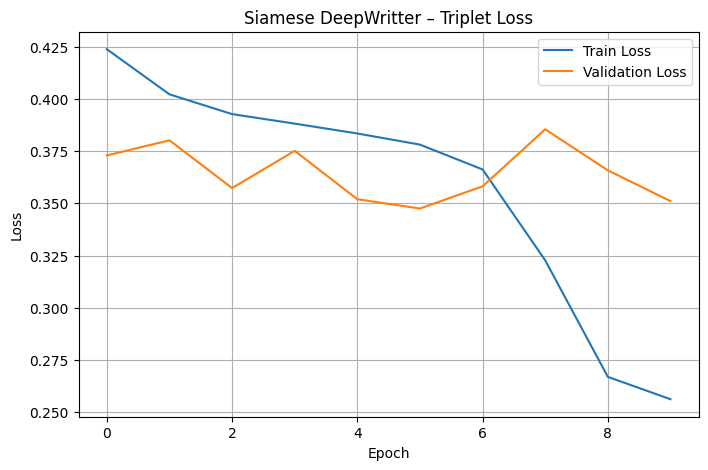

In [ ]:
plot_training_loss(
    cnn_history,
    title="Siamese DeepWritter – Triplet Loss"
)

In [ ]:
cnn_trainer.save(f"./models/siamese_cnn_{current_time}.keras")

07:27:26 - siamese_cnn_triplet_trainer - INFO - Model saved to models/siamese_cnn_20260207-055651.keras


In [28]:
cnn_trainer_new = ModelTrainer(
    backbone=DeepCNNBackbone(),
    input_shape=config['input_shape'],
    embedding_dim=config['embedding_dim'],
    model_name="siamese_triplet_cnn",
    log_dir=f"./logs_{current_time}"
)

17:02:08 - siamese_triplet_cnn_trainer - INFO - Model trainer initialized: siamese_triplet_cnn
17:02:08 - siamese_triplet_cnn_trainer - INFO - Input shape: (113, 113, 1)
17:02:08 - siamese_triplet_cnn_trainer - INFO - Embedding dim: 256


In [29]:
cnn_trainer_new.build(model_type="triplet")

17:02:12 - siamese_triplet_cnn_trainer - INFO - Building models...
17:02:13 - siamese_triplet_cnn_trainer - INFO - Model built: triplet_model
17:02:13 - siamese_triplet_cnn_trainer - INFO - Total params: 3391296
17:02:13 - siamese_triplet_cnn_trainer - INFO - Trainable params: 3388544


In [30]:
cnn_trainer_new.siamese_model.load_weights(
    f"./models/siamese_cnn_20260207-055651.keras"
)

In [34]:
from src.models.evaluation.verification import VerificationEvaluator
from src.models.evaluation.verification.thresholding import EERThresholdFinder

In [35]:
evaluator = VerificationEvaluator(
    model=cnn_trainer_new.siamese_model,
    model_name="siamese_cnn_triplet",
    model_type="triplet",
    threshold_finder=EERThresholdFinder(),
)

In [37]:
evaluator.model.summary()

Model: "triplet_model"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ anchor_input        │ (None, 113, 113,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ positive_input      │ (None, 113, 113,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ negative_input      │ (None, 113, 113,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ siamese_triplet_cn… │ (None, 256)       │  3,391,296 │ anchor_input[0][… │
│ (Functional)        │                   │            │ positive_input[0… │
│                     │                   │            │ negative_input[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stack (Stack)       │ (None, 3, 256)    │          0 │ siamese_triplet_… │
│                     │                   │            │ siamese_triplet_… │
│                     │                   │            │ siamese_triplet_… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 3,391,296 (12.94 MB)

 Trainable params: 3,388,544 (12.93 MB)

 Non-trainable params: 2,752 (10.75 KB)

In [36]:
val_results = evaluator.evaluate(
    generator=val_ds,
    steps=val_steps,
    threshold_strategy="eer"
)

17:09:30 - siamese_cnn_triplet_evaluator - INFO - Verification evaluation completed
17:09:30 - siamese_cnn_triplet_evaluator - INFO -   Accuracy:  0.6316
17:09:30 - siamese_cnn_triplet_evaluator - INFO -   AUC:       0.6958
17:09:30 - siamese_cnn_triplet_evaluator - INFO -   Precision: 0.6316
17:09:30 - siamese_cnn_triplet_evaluator - INFO -   Recall:    0.6316
17:09:30 - siamese_cnn_triplet_evaluator - INFO -   F1-score:  0.6316


In [38]:
optimal_threshold = val_results['threshold']
logger.info(f"Optimal EER threshold: {optimal_threshold:.4f}")

INFO - Optimal EER threshold: 0.7880


In [39]:
test_ds, test_steps = test_triplet_gen.to_dataset()

In [40]:
test_results = evaluator.evaluate(
    generator=test_ds,
    steps=test_steps,
    distance_threshold=optimal_threshold
)

17:12:00 - siamese_cnn_triplet_evaluator - INFO - Verification evaluation completed
17:12:00 - siamese_cnn_triplet_evaluator - INFO -   Accuracy:  0.7621
17:12:00 - siamese_cnn_triplet_evaluator - INFO -   AUC:       0.8516
17:12:00 - siamese_cnn_triplet_evaluator - INFO -   Precision: 0.7047
17:12:00 - siamese_cnn_triplet_evaluator - INFO -   Recall:    0.9024
17:12:00 - siamese_cnn_triplet_evaluator - INFO -   F1-score:  0.7914


In [41]:
distances = test_results['distances']
y_true = test_results['y_true']

INFO - Positive pairs - mean: 0.5025, std: 0.2023
INFO - Negative pairs - mean: 0.9050, std: 0.3127
INFO - Separation: 0.4025


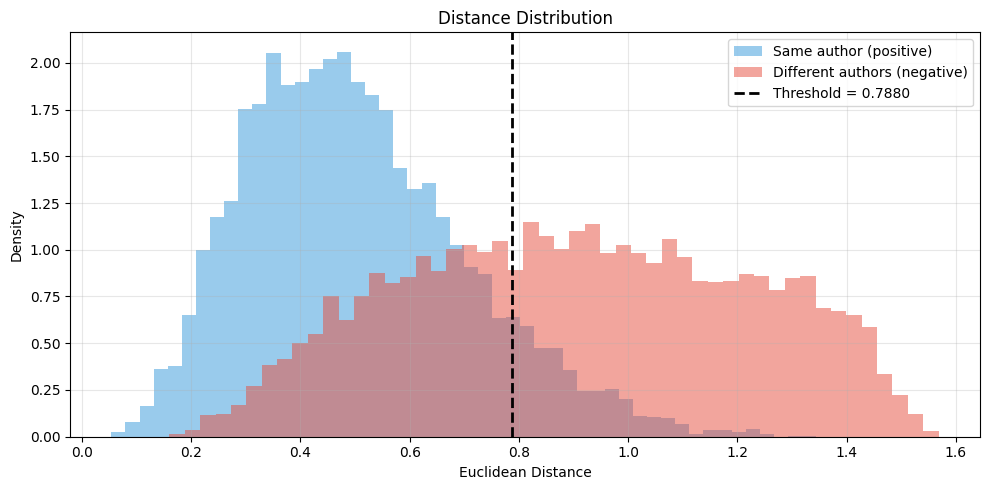

In [42]:
import matplotlib.pyplot as plt

pos_distances = distances[y_true == 1]
neg_distances = distances[y_true == 0]

logger.info(f"Positive pairs - mean: {pos_distances.mean():.4f}, std: {pos_distances.std():.4f}")
logger.info(f"Negative pairs - mean: {neg_distances.mean():.4f}, std: {neg_distances.std():.4f}")
logger.info(f"Separation: {neg_distances.mean() - pos_distances.mean():.4f}")

# Plot histograma
plt.figure(figsize=(10, 5))
plt.hist(pos_distances, bins=50, alpha=0.5, density=True, label='Same author (positive)', color='#3498db')
plt.hist(neg_distances, bins=50, alpha=0.5, density=True, label='Different authors (negative)', color='#e74c3c')
plt.axvline(x=optimal_threshold, color='k', linestyle='--', linewidth=2,
            label=f'Threshold = {optimal_threshold:.4f}')
plt.xlabel('Euclidean Distance')
plt.ylabel('Density')
plt.legend()
plt.title('Distance Distribution')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [43]:
from src.models.evaluation.identification import (
    IdentificationEvaluator,
    NearestMeanStrategy,
    VotingStrategy,
    MeanGalleryBuilder,
    FullGalleryBuilder,
)

In [44]:
from src.datasets import DataGenerator

In [46]:
id_eval = IdentificationEvaluator(
    embedding_model=cnn_trainer_new.embedding_model,
    strategy=NearestMeanStrategy(),
    gallery_builder=MeanGalleryBuilder(),
    mode="close-set",
)

In [47]:
test_gen = DataGenerator(
    data=subset.splits['test'],
    target_size=config['input_shape'][:2],
    batch_size=config['batch_size']['test'],
    use_augmentation=False,
    shuffle=False,
    seed=config['seed']
)

In [48]:
test_ds, test_steps = test_gen.to_dataset()

In [50]:
results = id_eval.evaluate(
    dataset=test_ds,
    steps=test_steps,
)

17:17:37 - embedding_model_identification - INFO - Starting identification evaluation
17:17:37 - embedding_model_identification - INFO -   Strategy: NearestMeanStrategy
17:17:37 - embedding_model_identification - INFO -   Gallery ratio: 0.5
17:17:37 - embedding_model_identification - INFO -   Min probe samples: 2
17:17:37 - embedding_model_identification - INFO - Extracting embeddings from 776 batches...
17:17:37 - embedding_model_identification - INFO -   Processing batch 1/776...
17:17:40 - embedding_model_identification - INFO -   Processing batch 78/776...
17:17:41 - embedding_model_identification - INFO -   Processing batch 155/776...
17:17:43 - embedding_model_identification - INFO -   Processing batch 232/776...
17:17:45 - embedding_model_identification - INFO -   Processing batch 309/776...
17:17:47 - embedding_model_identification - INFO -   Processing batch 386/776...
17:17:49 - embedding_model_identification - INFO -   Processing batch 463/776...
17:17:50 - embedding_model_i

In [51]:
results.keys()

dict_keys(['accuracy', 'num_authors', 'y_true', 'y_pred', 'details'])

In [52]:
results['details'][0].keys()

dict_keys(['true_author_id', 'pred_author_id', 'scores', 'min_distance', 'confidence'])

In [53]:
import pandas as pd

def identification_results_to_df(res: dict) -> pd.DataFrame:
    """
    Convert identification results to a per-author DataFrame.
    """
    df = pd.DataFrame(res["details"])

    # Ensure proper dtypes
    df["true_author_id"] = df["true_author_id"].astype(int)
    df["pred_author_id"] = df["pred_author_id"].astype(int)
    df["min_distance"] = df["min_distance"].astype(float)
    df["confidence"] = df["confidence"].astype(float)

    return df

In [54]:
def extract_identification_summary(res: dict) -> dict[str, float | int]:
    """
    Extract high-level identification metrics.
    """
    return {
        "accuracy": res["accuracy"],
        "num_authors": res["num_authors"],
        "y_true": res["y_true"],
        "y_pred": res["y_pred"],
    }

In [55]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, accuracy_score
import numpy as np

def plot_confusion_matrix(
    y_true: np.ndarray,
    y_pred: np.ndarray,
    title: str,
    normalize: bool = True
) -> None:
    acc = accuracy_score(y_true, y_pred)
    cm = confusion_matrix(
        y_true,
        y_pred,
        normalize='true' if normalize else None,
    )
    fig, ax = plt.subplots(figsize=(8, 8))
    cax = ax.matshow(cm, cmap=plt.cm.Blues)
    fig.colorbar(cax, ax=ax)

    ax.set_title(f"{title} (Acc: {acc:.2%})", fontsize=12)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")

    plt.tight_layout()
    plt.show()

In [56]:
res = identification_results_to_df(results)
summary = extract_identification_summary(results)

In [57]:
logger.info(f"Identification summary: {summary['accuracy']} - {summary['num_authors']}")

INFO - Identification summary: 1.0 - 50


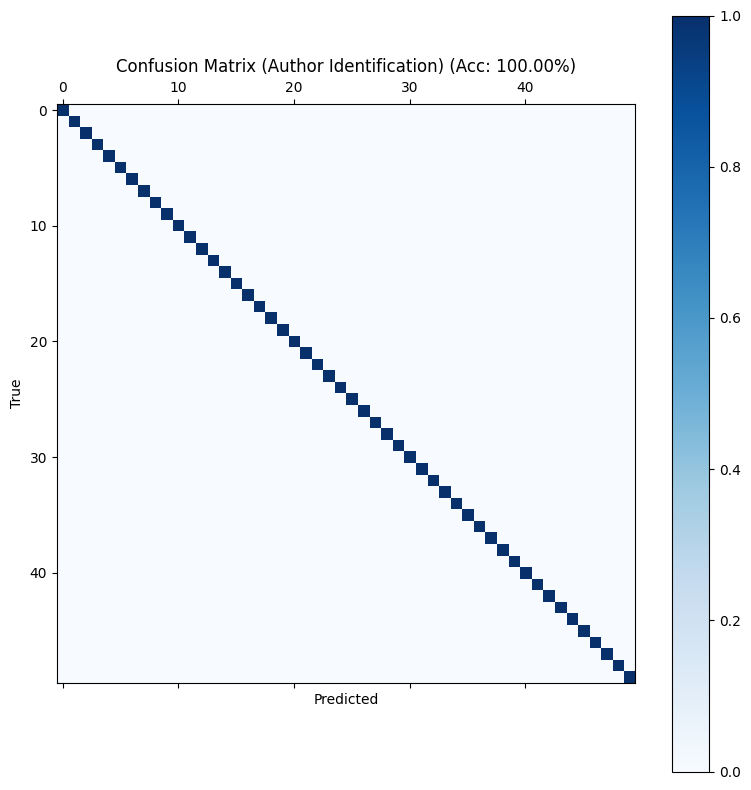

In [58]:
plot_confusion_matrix(
    summary["y_true"],
    summary["y_pred"],
    title="Confusion Matrix (Author Identification)",
    normalize=True,
)

In [ ]:
res

In [61]:
evaluator_voting = IdentificationEvaluator(
    embedding_model=cnn_trainer_new.embedding_model,
    strategy=VotingStrategy(distance_threshold=optimal_threshold),
    gallery_builder=FullGalleryBuilder(),
    mode="close-set",
)

In [62]:
voting_results = evaluator_voting.evaluate(
    dataset=test_ds,
    steps=test_steps,
)

17:23:37 - embedding_model_identification - INFO - Starting identification evaluation
17:23:37 - embedding_model_identification - INFO -   Strategy: VotingStrategy
17:23:37 - embedding_model_identification - INFO -   Gallery ratio: 0.5
17:23:37 - embedding_model_identification - INFO -   Min probe samples: 2
17:23:37 - embedding_model_identification - INFO - Extracting embeddings from 776 batches...
17:23:37 - embedding_model_identification - INFO -   Processing batch 1/776...
17:23:39 - embedding_model_identification - INFO -   Processing batch 78/776...
17:23:41 - embedding_model_identification - INFO -   Processing batch 155/776...
17:23:43 - embedding_model_identification - INFO -   Processing batch 232/776...
17:23:44 - embedding_model_identification - INFO -   Processing batch 309/776...
17:23:46 - embedding_model_identification - INFO -   Processing batch 386/776...
17:23:48 - embedding_model_identification - INFO -   Processing batch 463/776...
17:23:50 - embedding_model_identi

In [63]:
voting_results.keys()

dict_keys(['accuracy', 'num_authors', 'y_true', 'y_pred', 'details'])

In [65]:
voting_results['details'][0].keys()

dict_keys(['true_author_id', 'pred_author_id', 'scores', 'confidence'])

In [68]:
# voting_res = identification_results_to_df(voting_results)
voting_summary = extract_identification_summary(voting_results)

In [69]:
logger.info(f"Identification by voting summary: {voting_summary['accuracy']} - {voting_summary['num_authors']}")

INFO - Identification by voting summary: 0.32 - 50


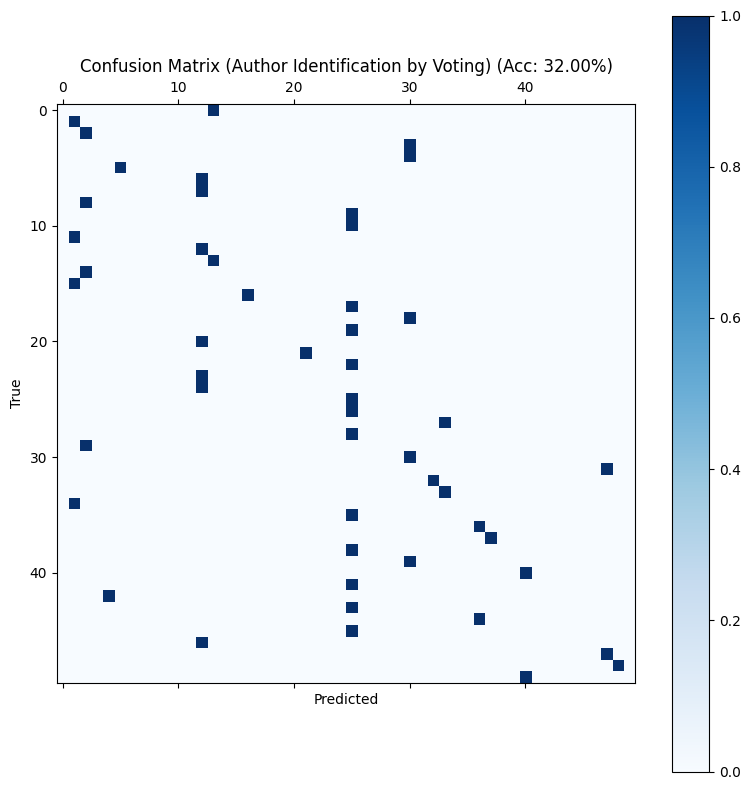

In [70]:
plot_confusion_matrix(
    voting_summary["y_true"],
    voting_summary["y_pred"],
    title="Confusion Matrix (Author Identification by Voting)",
    normalize=True,
)